In [2]:
import tudatpy

# Load standard modules
import numpy as np
from matplotlib import pyplot as plt
# import matplotlib
# matplotlib.use('QtAgg')  # or try 'QtAgg'
# import matplotlib.pyplot as plt

# Load tudatpy modules
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup, propagation_setup, simulator
from tudatpy.astro import element_conversion
from tudatpy import constants
from tudatpy.util import result2array
from tudatpy.astro.time_representation import DateTime

In [16]:

# Load spice kernels
spice.load_standard_kernels()

# Set simulation start and end epochs
# So here end of the epoch is a day later :)
# The start day is set to be 1st of January 2000 

simulation_start_epoch = DateTime(2000, 1, 1).to_epoch()
simulation_end_epoch   = DateTime(2001, 1, 1).to_epoch()

# The start time is changed to 2025-Nov-21 (see JPL Horizon --> initial condition)

# simulation_start_epoch = DateTime(2025, 9, 21).to_epoch()
# simulation_end_epoch   = DateTime(2026, 9, 21).to_epoch()



# ME TRYING TO FIND TU3

# I assume that I load the spice kernels and use the same start and stop time


# Create default body settings for the Sun
bodies_to_create_TU3 = ["Sun"]

# Create default body settings for bodies_to_create, with "Sun"/"J2000" as the global frame origin 
# and orientation
# So, we choose to consider the body of Sun

global_frame_origin_TU3 = "Sun"
# I believe we always choose this
global_frame_orientation_TU3 = "ECLIPJ2000"

body_settings_TU3 = environment_setup.get_default_body_settings(
    bodies_to_create_TU3, global_frame_origin_TU3, global_frame_orientation_TU3)

# Add empty settings to body settings
# Create the massless satellite for which the orbit around Sun will be propagated
body_settings_TU3.add_empty_settings("TU3-199")

# Create system of bodies (in this case only Sun)
bodies_TU3 = environment_setup.create_system_of_bodies(body_settings_TU3)

# Define bodies that are propagated
bodies_to_propagate_TU3 = ["TU3-199"]

# Define central bodies of propagation
central_bodies_TU3 = ["Sun"]


# Acceleration model:

# Define accelerations acting on TU3-1998
acceleration_settings_TU3 = dict(
    Sun=
    [
        propagation_setup.acceleration.point_mass_gravity(),
        # propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
        # propagation_setup.acceleration.yarkovsky(-2.65*10**(-14)),           # The Yarkovsky parameter
        # propagation_setup.acceleration.spherical_harmonic()                  # The solar quadrupole moment
    ],
)

acceleration_settings_TU3 = {"TU3-199": acceleration_settings_TU3}

# Create acceleration models
acceleration_models_TU3 = propagation_setup.create_acceleration_models(
    bodies_TU3, acceleration_settings_TU3, bodies_to_propagate_TU3, central_bodies_TU3
)

#--------------------------------------------

#Initial state

# Set initial conditions for the satellite that will be
# propagated in this simulation. The initial conditions are given in
# Keplerian elements and later on converted to Cartesian elements

# Let's just test what happens with the same initial state
sun_gravitational_parameter_TU3 = bodies_TU3.get("Sun").gravitational_parameter

# initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
#    gravitational_parameter = sun_gravitational_parameter_TU3,
#    semi_major_axis = 117815568541, #meters
#    eccentricity = 0.4836694929440215, #unitless
#    inclination = np.radians(5.415250040031074), #radians
#    argument_of_periapsis = np.radians(84.99253804349257),
#    longitude_of_ascending_node = np.radians(101.8786744779986),
#    true_anomaly = 2.2486890775e+00, #calculated with e, M, and E.
# )

# initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
#     sun_gravitational_parameter_TU3,
#     117815568541, #meters
#     0.4836694929440215, #unitless
#     np.radians(5.415250040031074), #radians
#     np.radians(84.99253804349257),
#     np.radians(101.8786744779986),
#     2.2486890775e+00, #calculated with e, M, and E.
# )


# Grabbing the initial state at 2000-01-01 from JPL with cartesian_to_keplarian() (in astro)


# Cartesian state vector
cartesian_elements = np.array([
    [4.543863572576185E+07 * 1e3],   # X  [m]
    [-9.673019712424231E+07 * 1e3],  # Y  [m]
    [-2.313075952057116E+06 * 1e3],  # Z  [m]
    [3.661410298575712E+01 * 1e3],   # VX [m/s]
    [-1.757686929389374E+00 * 1e3],  # VY [m/s]
    [-3.350242409196601E+00 * 1e3]   # VZ [m/s]
], dtype=np.float64)


test_initial_TU3_array = element_conversion.cartesian_to_keplerian(
    cartesian_elements = cartesian_elements,
    gravitational_parameter = sun_gravitational_parameter_TU3
)

print("Keplerian Elements:")
print(test_initial_TU3_array)
print(test_initial_TU3_array[0])
print(test_initial_TU3_array[2])


Keplerian Elements:
[1.17640978e+11 4.74911638e-01 9.41948277e-02 1.48670034e+00
 1.77880117e+00 1.88703315e+00]
117640977822.613
0.09419482774380611


In [17]:

# ---------------------------------
# Testing new initial condition

initial_state_TU3 = element_conversion.keplerian_to_cartesian_elementwise(
   gravitational_parameter = sun_gravitational_parameter_TU3,
   semi_major_axis = test_initial_TU3_array[0],                 #meters
   eccentricity = test_initial_TU3_array[1],                    #unitless
   inclination = test_initial_TU3_array[2],                     # cartesian_to_keplerian returns angles in radians
   argument_of_periapsis = test_initial_TU3_array[3],
   longitude_of_ascending_node = test_initial_TU3_array[4],
   true_anomaly = test_initial_TU3_array[5],                
)
# ---------------------------------

# Create termination settings
termination_settings_TU3 = propagation_setup.propagator.time_termination(simulation_end_epoch)

# Create numerical integrator settings
integrator_settings_TU3 = propagation_setup.integrator.runge_kutta_fixed_step(
    time_step = 24*3600.0,
    coefficient_set = propagation_setup.integrator.CoefficientSets.rk_4 )

# Create propagation settings
propagator_settings_TU3 = propagation_setup.propagator.translational(
    central_bodies_TU3,
    acceleration_models_TU3,
    bodies_to_propagate_TU3,
    initial_state_TU3,
    simulation_start_epoch,
    integrator_settings_TU3,
    termination_settings_TU3
)



# Create simulation object and propagate the dynamics
dynamics_simulator_TU3 = simulator.create_dynamics_simulator(
    bodies_TU3, propagator_settings_TU3
)
# Extract the resulting state history and convert it to an ndarray
states_TU3 = dynamics_simulator_TU3.propagation_results.state_history
states_array_TU3 = result2array(states_TU3)

print(
    f"""
Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: \n{
    states_TU3[simulation_start_epoch][:3] / 1E3}
The initial velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_start_epoch][3:] / 1E3}
\nAfter {simulation_end_epoch} seconds the position vector of TU3 is [km]: \n{
    states_TU3[simulation_end_epoch][:3] / 1E3}
And the velocity vector of TU3 is [km/s]: \n{
    states_TU3[simulation_end_epoch][3:] / 1E3}
    """
)



Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: 
[ 45438635.72576186 -96730197.12424232  -2313075.95205713]
The initial velocity vector of TU3 is [km/s]: 
[36.61410299 -1.75768693 -3.35024241]

After 31622400.0 seconds the position vector of TU3 is [km]: 
[ 1.59909352e+08  5.57649354e+07 -1.58696597e+07]
And the velocity vector of TU3 is [km/s]: 
[-10.27942189  18.06392851   0.59778671]
    


In [18]:
# # To examine how far apart the "real" values of TU3 are from JPL Horizon

# # All the states made by Tudat are put into statues_TU3
# print(len(states_TU3))


# # Extract columns
# t_TU3  = states_array_TU3[:, 0]

# x_TU3  = states_array_TU3[:, 1]
# y_TU3  = states_array_TU3[:, 2]
# z_TU3  = states_array_TU3[:, 3]

# vx_TU3 = states_array_TU3[:, 4]
# vy_TU3 = states_array_TU3[:, 5]
# vz_TU3 = states_array_TU3[:, 6]

# print(x_TU3[0])

# # After having imported and created the data in another python file
# # Extract the data from a CSV file:
# import pandas as pd

# # Load CSV
# csv_data = pd.read_csv("/home/emmabob/Bachelor_Project/TU3/asteroid_66146_vectors.csv")
# # csv_data = pd.read_csv("/home/emmabob/Bachelor_Project/TU3/2025_Nov_21_JPL_vectors.csv")

# # Convert columns to arrays
# x_JPL = csv_data["x"].to_numpy() * 1e3  # km to m
# y_JPL = csv_data["y"].to_numpy() * 1e3
# z_JPL = csv_data["z"].to_numpy() * 1e3

# vx_JPL = csv_data["vx"].to_numpy() * 1e3    # km/s to m/s
# vy_JPL = csv_data["vy"].to_numpy() * 1e3
# vz_JPL = csv_data["vz"].to_numpy() * 1e3

# print(states_TU3[0])
# print(states_array_TU3[5])
# print(x_JPL[0])


# # Then compare the values from Tudat and JPL Horizon
 
# x_comp = x_TU3 - x_JPL 
# y_comp = y_TU3 - y_JPL
# z_comp = z_TU3 - z_JPL

# vx_comp = vx_TU3 - vx_JPL 
# vy_comp = vy_TU3 - vy_JPL
# vz_comp = vz_TU3 - vz_JPL


# # Printing the difference

# import matplotlib.pyplot as plt

# t_TU3_days = t_TU3 / (24*3600)  # From seconds to days


# # =========================
# # POSITION DIFFERENCES
# # =========================

# plt.figure(figsize=(10, 6))

# plt.plot(t_TU3_days, x_comp, label='x difference')
# plt.plot(t_TU3_days, y_comp, label='y difference')
# plt.plot(t_TU3_days, z_comp, label='z difference')

# plt.xlabel('Time')
# plt.ylabel('Position Difference [m]')
# plt.title('Tudat vs JPL Position Differences')

# plt.legend()
# plt.grid(True)

# # plt.show()


# # =========================
# # VELOCITY DIFFERENCES
# # =========================

# plt.figure(figsize=(10, 6))

# plt.plot(t_TU3_days, vx_comp, label='vx difference')
# plt.plot(t_TU3_days, vy_comp, label='vy difference')
# plt.plot(t_TU3_days, vz_comp, label='vz difference')

# plt.xlabel('Time')
# plt.ylabel('Velocity Difference [m/s]')
# plt.title('Tudat vs JPL Velocity Differences')

# plt.legend()
# plt.grid(True)

# # plt.show()




# # Printing the orbit:

# # # Define a 3D figure using pyplot
# # fig = plt.figure(figsize=(6,6), dpi=125)
# # ax = fig.add_subplot(111, projection='3d')
# # ax.set_title(f'TU3 trajectory around Sun')

# # # Plot the positional state history
# # ax.plot(states_array_TU3[:, 1], states_array_TU3[:, 2], states_array_TU3[:, 3], label=bodies_to_propagate_TU3[0], linestyle='-.')
# # ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='orange')

# # print("Before final graph")

# # # Add the legend and labels, then show the plot
# # ax.legend()
# # ax.set_xlabel('x [m]')
# # ax.set_ylabel('y [m]')
# # ax.set_zlabel('z [m]')
# # ax.set_aspect('equal')
# # plt.show()
# # plt.close('all')

# # print("End of code")



Before final graph


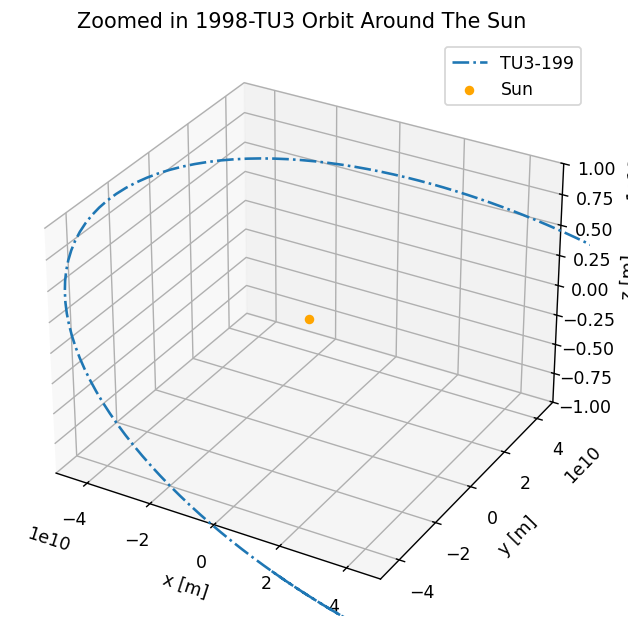

End of code


In [19]:
# Printing the orbit:

# Define a 3D figure using pyplot
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'Zoomed in 1998-TU3 Orbit Around The Sun')

# Plot the positional state history
ax.plot(states_array_TU3[:, 1], states_array_TU3[:, 2], states_array_TU3[:, 3], label=bodies_to_propagate_TU3[0], linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='orange')

print("Before final graph")

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')

#ax.set_aspect('equal')
# TU3 Orbit
ax.set_xlim(-5e10, 5e10)
ax.set_ylim(-5e10, 5e10)
ax.set_zlim(-1e10, 1e10)

plt.show()
plt.close('all')

print("End of code")

Before final graph


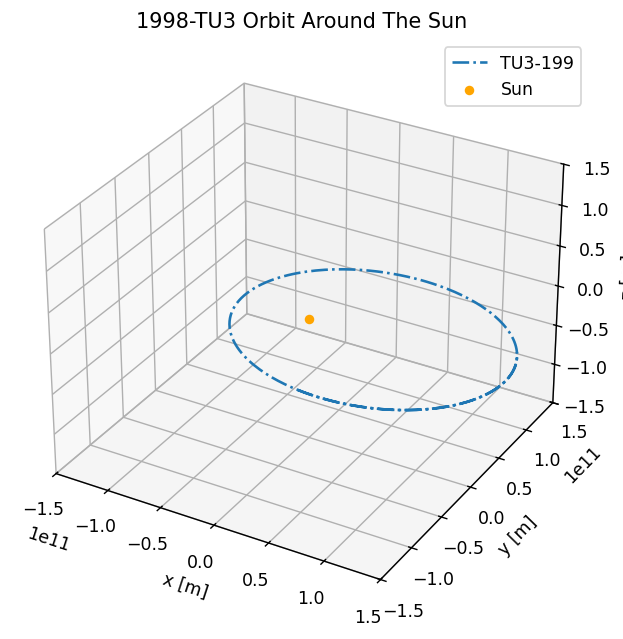

End of code


In [20]:
# Printing the zoomed in orbit:

# Define a 3D figure using pyplot
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'1998-TU3 Orbit Around The Sun')

# Plot the positional state history
ax.plot(states_array_TU3[:, 1], states_array_TU3[:, 2], states_array_TU3[:, 3], label=bodies_to_propagate_TU3[0], linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='orange')

print("Before final graph")

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')

# ax.set_aspect('equal')
# TU3 Orbit
ax.set_xlim(-1.5e11, 1.5e11)
ax.set_ylim(-1.5e11, 1.5e11)
ax.set_zlim(-1.5e11, 1.5e11)

plt.show()
plt.close('all')

print("End of code")


In [21]:
# Check the difference in Cartesian coordinates

# Perihelion in 1st orbit: 18835200.0 seconds
# Perihelion in 2nd orbit: 40863600.0 seconds

period_seconds = 40863600.0 - 18835200.0
period_days = period_seconds / (3600 * 24)
print(period_days)
orbit_percentage = period_days / 365.25

# So, theoretically the coordinates should be at the exact same place

period_test_start = DateTime(2000, 1, 1).to_epoch()
period_test_stop = period_test_start +  255 * constants.JULIAN_DAY

print(
    f"""
Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: \n{
    states_TU3[period_test_start][:3] / 1E3}
The initial velocity vector of TU3 is [km/s]: \n{
    states_TU3[period_test_start][3:] / 1E3}
\nAfter {period_test_stop} seconds the position vector of TU3 is [km]: \n{
    states_TU3[period_test_stop][:3] / 1E3}
And the velocity vector of TU3 is [km/s]: \n{
    states_TU3[period_test_stop][3:] / 1E3}
    """
)

difference_position = states_TU3[period_test_start][:3] - states_TU3[period_test_stop][:3]
print(difference_position)

254.95833333333334

Single Sun-Orbiting Satellite Example.
The initial position vector of TU3 is [km]: 
[ 45438635.72576186 -96730197.12424232  -2313075.95205713]
The initial velocity vector of TU3 is [km/s]: 
[36.61410299 -1.75768693 -3.35024241]

After 22032000.0 seconds the position vector of TU3 is [km]: 
[ 46350409.4009224  -96770700.41048126  -2396568.27775758]
And the velocity vector of TU3 is [km/s]: 
[36.49048913 -1.49702651 -3.34390121]
    
[-9.11773675e+08  4.05032862e+07  8.34923257e+07]


367
[ 4.54386357e+10 -9.67301971e+10 -2.31307595e+09  3.66141030e+04
 -1.75768693e+03 -3.35024241e+03]
[ 4.32000000e+05  6.07772738e+10 -9.65711050e+10 -3.73405281e+09
  3.43635322e+04  2.35775995e+03 -3.22249544e+03]
45438635725.761856


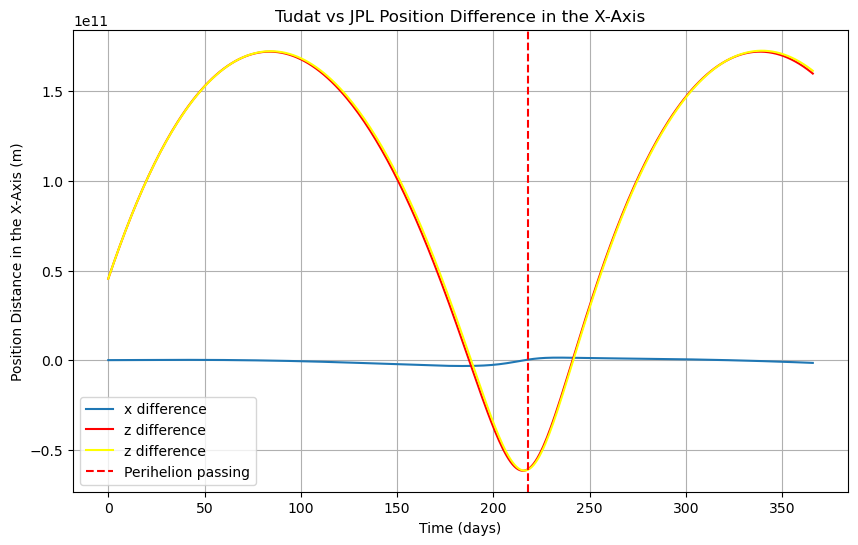

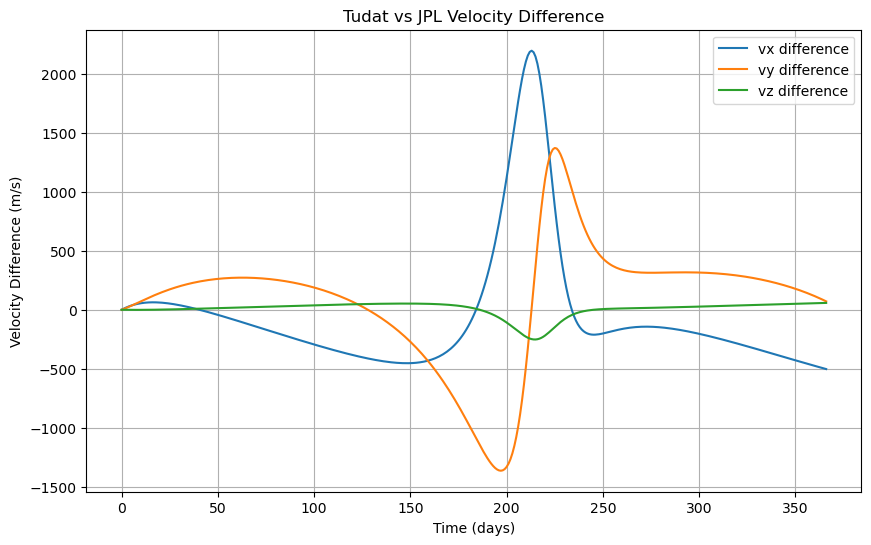

In [ ]:
# Examine how far apart the simulated values of TU3 are from JPL Horizon

# All the states made by Tudat are put into statues_TU3
print(len(states_TU3))

# Extract columns
t_TU3  = states_array_TU3[:, 0]

x_TU3  = states_array_TU3[:, 1]
y_TU3  = states_array_TU3[:, 2]
z_TU3  = states_array_TU3[:, 3]

vx_TU3 = states_array_TU3[:, 4]
vy_TU3 = states_array_TU3[:, 5]
vz_TU3 = states_array_TU3[:, 6]

# print(x_TU3[0])

# After having imported and created the data in another python file
# Extract the data from a CSV file:
import pandas as pd

# Load CSV
csv_data = pd.read_csv("/home/emmabob/Bachelor_Project/TU3/asteroid_66146_vectors.csv")
# csv_data = pd.read_csv("/home/emmabob/Bachelor_Project/TU3/2025_Nov_21_JPL_vectors.csv")

# Convert columns to arrays
x_JPL = csv_data["x"].to_numpy() * 1e3  # km to m
y_JPL = csv_data["y"].to_numpy() * 1e3
z_JPL = csv_data["z"].to_numpy() * 1e3

vx_JPL = csv_data["vx"].to_numpy() * 1e3    # km/s to m/s
vy_JPL = csv_data["vy"].to_numpy() * 1e3
vz_JPL = csv_data["vz"].to_numpy() * 1e3

print(states_TU3[0])
print(states_array_TU3[5])
print(x_JPL[0])


# Then compare the values from Tudat and JPL Horizon
 
x_comp = x_TU3 - x_JPL 
y_comp = y_TU3 - y_JPL
z_comp = z_TU3 - z_JPL

vx_comp = vx_TU3 - vx_JPL 
vy_comp = vy_TU3 - vy_JPL
vz_comp = vz_TU3 - vz_JPL


# Printing the difference

t_TU3_days = t_TU3 / (24*3600)  # From seconds to days
perihelion_time = 18838800.0 / (24*3600)    # This time is found in the Jupyter Notebook TU3_orbit_precession_2.ipynb

# =========================
# POSITION DIFFERENCES
# =========================

plt.figure(figsize=(10, 6))

plt.plot(t_TU3_days, x_comp, label='x difference')
plt.plot(t_TU3_days, y_comp, label='y difference')
plt.plot(t_TU3_days, z_comp, label='z difference')
# plt.plot(t_TU3_days, x_TU3, label='z difference', color='red')        # Tudat x-position
# plt.plot(t_TU3_days, x_JPL, label='z difference', color='yellow')     # JPL x-position
# plt.axvline(perihelion_time, label='Perihelion passing', color='red', linestyle='--', linewidth=1.5)      # Perihelion time

plt.xlabel('Time (days)')
plt.ylabel('Position Distance in the X-Axis (m)')
plt.title('Tudat vs JPL Position Difference in the X-Axis')

plt.legend()
plt.grid(True)

plt.show()


# =========================
# VELOCITY DIFFERENCES
# =========================

plt.figure(figsize=(10, 6))

plt.plot(t_TU3_days, vx_comp, label='vx difference')
plt.plot(t_TU3_days, vy_comp, label='vy difference')
plt.plot(t_TU3_days, vz_comp, label='vz difference')

plt.xlabel('Time (days)')
plt.ylabel('Velocity Difference (m/s)')
plt.title('Tudat vs JPL Velocity Difference')

plt.legend()
plt.grid(True)

plt.show()

Before final graph


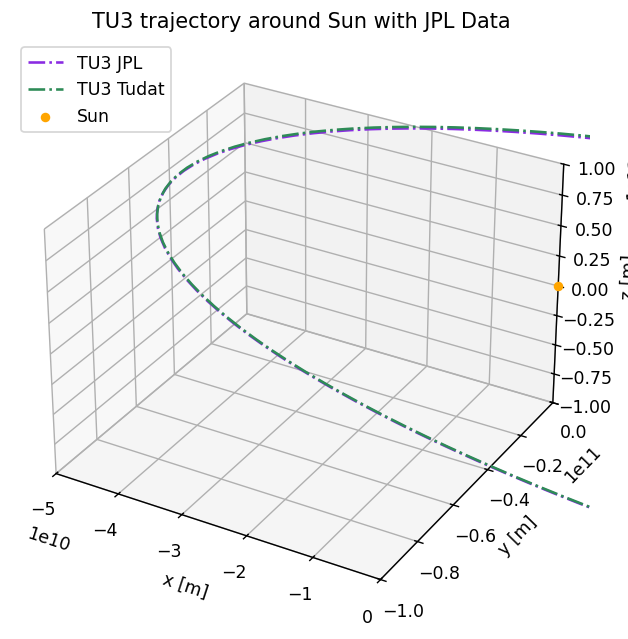

End of code


In [23]:

# Printing the orbit:

# Define a 3D figure using pyplot
fig = plt.figure(figsize=(6,6), dpi=125)
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f'TU3 trajectory around Sun with JPL Data')

# Plot the positional state history
ax.plot(x_JPL, y_JPL, z_JPL, label="TU3 JPL", color='blueviolet', linestyle='-.')
ax.plot(states_array_TU3[:, 1], states_array_TU3[:, 2], states_array_TU3[:, 3], label="TU3 Tudat", color='seagreen', linestyle='-.')
ax.scatter(0.0, 0.0, 0.0, label="Sun", marker='o', color='orange')

print("Before final graph")

# Add the legend and labels, then show the plot
ax.legend()
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_xlim(-0.5e11, 0)
ax.set_ylim(-1e11, 0)
ax.set_zlim(-1e11, 1e11)

#ax.set_aspect('equal')
plt.show()
plt.close('all')

print("End of code")


In [7]:
# # Viasualisation with code:

# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from mpl_toolkits.mplot3d import Axes3D

# # ==========================================
# # ASSUMED ARRAYS
# # ==========================================
# # x_TU3, y_TU3, z_TU3
# # x_JPL, y_JPL, z_JPL
# #
# # all arrays must have same length
# # ==========================================

# # Create figure
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')

# # ==========================================
# # PLOT COMPLETE ORBITS
# # ==========================================

# ax.plot(
#     x_JPL,
#     y_JPL,
#     z_JPL,
#     '--',
#     label='TU3 JPL'
# )

# ax.plot(
#     x_TU3,
#     y_TU3,
#     z_TU3,
#     '-.',
#     label='TU3 Tudat'
# )

# # Sun at origin
# ax.scatter(
#     0,
#     0,
#     0,
#     s=100,
#     label='Sun',
#     color='orange'
# )

# # ==========================================
# # ANIMATED POINTS
# # ==========================================

# # JPL asteroid point
# point_JPL, = ax.plot(
#     [],
#     [],
#     [],
#     'o',
#     markersize=8,
#     label='JPL Position'
# )

# # Tudat asteroid point
# point_TU3, = ax.plot(
#     [],
#     [],
#     [],
#     'o',
#     markersize=8,
#     label='Tudat Position'
# )

# # ==========================================
# # AXIS LABELS
# # ==========================================

# ax.set_xlabel('x [m]')
# ax.set_ylabel('y [m]')
# ax.set_zlabel('z [m]')

# ax.set_title('TU3 Orbit Animation')

# ax.legend()

# # ==========================================
# # EQUAL AXIS SCALING
# # ==========================================

# max_range = np.array([
#     x_TU3.max() - x_TU3.min(),
#     y_TU3.max() - y_TU3.min(),
#     z_TU3.max() - z_TU3.min()
# ]).max() / 2.0

# mid_x = (x_TU3.max() + x_TU3.min()) * 0.5
# mid_y = (y_TU3.max() + y_TU3.min()) * 0.5
# mid_z = (z_TU3.max() + z_TU3.min()) * 0.5

# ax.set_xlim(mid_x - max_range, mid_x + max_range)
# ax.set_ylim(mid_y - max_range, mid_y + max_range)
# ax.set_zlim(mid_z - max_range, mid_z + max_range)

# # ==========================================
# # INITIALIZATION FUNCTION
# # ==========================================

# def init():

#     point_JPL.set_data([], [])
#     point_JPL.set_3d_properties([])

#     point_TU3.set_data([], [])
#     point_TU3.set_3d_properties([])

#     return point_JPL, point_TU3

# # ==========================================
# # ANIMATION FUNCTION
# # ==========================================

# def update(frame):

#     # Update JPL point
#     point_JPL.set_data(
#         [x_JPL[frame]],
#         [y_JPL[frame]]
#     )

#     point_JPL.set_3d_properties(
#         [z_JPL[frame]]
#     )

#     # Update Tudat point
#     point_TU3.set_data(
#         [x_TU3[frame]],
#         [y_TU3[frame]]
#     )

#     point_TU3.set_3d_properties(
#         [z_TU3[frame]]
#     )

#     return point_JPL, point_TU3

# # ==========================================
# # CREATE ANIMATION
# # ==========================================

# ani = FuncAnimation(
#     fig,
#     update,
#     frames=len(x_TU3),
#     init_func=init,
#     interval=30,      # milliseconds between frames
#     blit=True
# )

# plt.show()



In [34]:
# ========================================
# Testing for the perihelion precession:

from tudatpy.kernel.astro import element_conversion

kepler_history = {}

for epoch, state in states_TU3.items():

    # Convert from Cartesian to Keplerian coordinates
    kepler = element_conversion.cartesian_to_keplerian(
        cartesian_elements = state,     # x, y, z, vx, vy, vz at each step (3600.0 seconds)
        gravitational_parameter = sun_gravitational_parameter_TU3
    )

    # Fill up the dictionary
    kepler_history[epoch] = kepler




In [35]:

epochs = []
omega_values_anglejump = []
true_anomaly_list = []
epoch_perihelion_list = []
index_list_peri = []

# To detect the perihelion in time
previous_nu = None

for i, (epoch, kep) in enumerate(kepler_history.items(), start=1):

    # Extract the true anomaly
    nu = kep[5]

    if previous_nu is not None:

        # Detect wraparound near perihelion
        # Cause there will be a jump from 2pi to 0
        if previous_nu > (3/2)*np.pi and nu < (1/2)*np.pi:
            
            epoch_perihelion_close = epoch
            epoch_perihelion_list.append(epoch_perihelion_close)
            index_list_peri.append(i)

            # epoch_days = epoch / (3600*24)
            # print(f"The perihelion is near the epoch of {epoch_perihelion_close}")

    previous_nu = nu

    # Extract the perihelion precession as well

    omega_test = kep[3]
    epochs.append(epoch)

    omega_values_anglejump.append(omega_test)

# Unwrap the angles :)
# Makes e.g. 359, 0, 1 degrees to 359, 360, 361 etc.
omega_values = np.unwrap(omega_values_anglejump)

print(f"The list of when the perihelion occurs (in seconds): {epoch_perihelion_list}")
print(f"The index which is closest to the perihelion: {index_list_peri}")


# # The perihelion precession during the first year:
# first_peri = perihelion_precess = np.degrees(omega_values[5234] -  omega_values[0])
# # The perihelion precession after 15 years
# peri_precess_15_years = np.degrees(omega_values[-1] - omega_values[5234])

peri_precession_per_orbit_list = []

for i in index_list_peri:
    peri_deg = perihelion_precess = np.degrees(omega_values[i+1] -  omega_values[i])
    peri_precession_per_orbit_list.append(peri_deg)

# print(first_peri)
# print(peri_precess_15_years)
print(f"The perihelion occurs at the omega of: {omega_values[219]}")
print(peri_precession_per_orbit_list)



The list of when the perihelion occurs (in seconds): [18835200.0]
The index which is closest to the perihelion: [219]
The perihelion occurs at the omega of: 1.486701218204773
[5.383497245209195e-06]


In [37]:


# plt.plot(peri_precession_per_orbit_list)
# plt.ylabel('The perihelion precession (in degrees)')
# plt.show()

# omega_deg = np.degrees(omega_values) * 3600 # arcseconds

# time_years = np.array(epochs) / (100 * 3600 * 24 * 365.25)

# coeffs = np.polyfit(
#     time_years,
#     omega_deg,
#     1
# )

# slope_deg_per_year = coeffs[0]
# print(slope_deg_per_year)


# Second attempt:

# omega_deg = np.degrees(omega_values) * 3600 # arcseconds
# time_years = np.array(epochs) / (100 * 3600 * 24 * 365.25)

perihelion_test = np.array(peri_precession_per_orbit_list) * 3600
epoch_test = np.array(epoch_perihelion_list) / (100 * 3600 * 24 * 365.25)

coeffs_test = np.polyfit(
    epoch_test,
    #time_years,
    perihelion_test,
    #omega_deg,
    1
)

slope_deg_per_century_test = coeffs_test[0]
print(f"Perihelion precession of: {slope_deg_per_century_test:4f} arcseconds / century")
# print(coeffs)

Perihelion precession of: 1.623569 arcseconds / century


/tmp/ipykernel_135124/2934733761.py:27: RankWarning: Polyfit may be poorly conditioned
  coeffs_test = np.polyfit(
